In [1]:
import pandas as pd

# Load the breaches file
df = pd.read_csv("Balloon Race Data Breaches - LATEST - breaches.csv")

# How big is it? (rows, columns)
print("Rows and columns:", df.shape)

# Show the first 5 rows
df.head()

Rows and columns: (418, 16)


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,organisation,alternative name,records lost,year,date,story,sector,method,interesting story,data sensitivity,displayed records,Unnamed: 11,source name,1st source link,2nd source link,ID
0,visualisation here: https://informationisbeaut...,NaN,"(use 3m, 4m, 5m or 10m to approximate unknown ...",year story broke,NaN,NaN,web\nhealthcare\napp\nretail\ngaming\ntranspor...,poor security\nhacked\noops!\nlost device \nin...,NaN,1. Just email address/Online information \n2 S...,"=IF(C3>100000000,C3,"")",NaN,NaN,NaN,NaN,NaN
1,Plex,NaN,"15,000,000",2022,Aug 2022,"Intruders access password data, usernames, and...",web,hacked,NaN,1,NaN,NaN,Ars technica,https://arstechnica.com/information-technology...,NaN,418.0
2,Twitter,NaN,"5,400,000",2021,Dec 2021,Zero day vulnerability allowed a threat actor ...,web,hacked,NaN,2,NaN,NaN,Bleeping Computer,https://www.bleepingcomputer.com/news/security...,NaN,419.0
3,Shanghai Police,NaN,"500,000,000",2022,Jul 2022,A database containing records of over a billio...,financial,hacked,NaN,5,"""one billion""",NaN,The Register,https://www.theregister.com/2022/07/05/shangha...,NaN,420.0
4,"City of Amagasaki, Japan",NaN,"500,000",2022,Jun 2022,An unnamed government official lost his bag af...,government,oops!,NaN,3,NaN,NaN,BBC,https://www.bbc.co.uk/news/world-asia-61921222,NaN,421.0


In [2]:
# --- Stage 2: Clean the breaches data ---

# 1. Drop the junk legend row (row 0), reset the index
clean = df.drop(0).reset_index(drop=True)

# 2. Keep only the columns we need for our question
clean = clean[["organisation", "records lost", "year", "sector", "method", "data sensitivity"]].copy()

# 3. Rename to short, clean names
clean.columns = ["organisation", "records_lost", "year", "sector", "method", "sensitivity"]

# Show how many rows remain and preview
print("Rows after dropping junk:", clean.shape[0])
clean.head()

KeyError: "['year'] not in index"

In [3]:
# Show each column name wrapped in quotes, so hidden spaces become visible
for c in df.columns:
    print(repr(c))

'organisation'
'alternative name'
'records lost'
'year   '
'date'
'story'
'sector'
'method'
'interesting story'
'data sensitivity'
'displayed records'
'Unnamed: 11'
'source name'
'1st source link'
'2nd source link'
'ID'


In [4]:
# --- Stage 2: Clean the breaches data ---

# 1. Strip hidden spaces off ALL column names first (fixes 'year   ' etc.)
df.columns = df.columns.str.strip()

# 2. Drop the junk legend row (row 0), reset the index
clean = df.drop(0).reset_index(drop=True)

# 3. Keep only the columns we need
clean = clean[["organisation", "records lost", "year", "sector", "method", "data sensitivity"]].copy()

# 4. Rename to short, clean names
clean.columns = ["organisation", "records_lost", "year", "sector", "method", "sensitivity"]

# Show how many rows remain and preview
print("Rows after dropping junk:", clean.shape[0])
clean.head()

Rows after dropping junk: 417


,organisation,records_lost,year,sector,method,sensitivity
0,Plex,"15,000,000",2022,web,hacked,1
1,Twitter,"5,400,000",2021,web,hacked,2
2,Shanghai Police,"500,000,000",2022,financial,hacked,5
3,"City of Amagasaki, Japan","500,000",2022,government,oops!,3
4,Dubai Real Estate Leak,"800,000",2022,financial,inside job,1


In [5]:
# Convert records_lost from text (with commas) into real numbers

# Remove commas, then convert to a number. Anything that can't convert becomes NaN (blank).
clean["records_lost"] = clean["records_lost"].str.replace(",", "", regex=False)
clean["records_lost"] = pd.to_numeric(clean["records_lost"], errors="coerce")

# Also make sure year and sensitivity are numbers
clean["year"] = pd.to_numeric(clean["year"], errors="coerce")
clean["sensitivity"] = pd.to_numeric(clean["sensitivity"], errors="coerce")

# Check: how many records_lost values failed to convert (are now blank)?
print("Blank records_lost values:", clean["records_lost"].isna().sum())
print("\nData types now:")
print(clean.dtypes)

clean.head()

Blank records_lost values: 0

Data types now:
organisation     object
records_lost      int64
year              int64
sector           object
method           object
sensitivity     float64
dtype: object


,organisation,records_lost,year,sector,method,sensitivity
0,Plex,15000000,2022,web,hacked,1.0
1,Twitter,5400000,2021,web,hacked,2.0
2,Shanghai Police,500000000,2022,financial,hacked,5.0
3,"City of Amagasaki, Japan",500000,2022,government,oops!,3.0
4,Dubai Real Estate Leak,800000,2022,financial,inside job,1.0


In [6]:
# Inspect the sector and method labels - see all unique values and their counts

print("=== SECTORS ===")
print(clean["sector"].value_counts())

print("\n=== METHODS ===")
print(clean["method"].value_counts())


=== SECTORS ===
sector
web                     108
government               44
health                   43
finance                  39
retail                   37
telecoms                 22
app                      21
tech                     20
transport                17
gaming                   16
academic                 11
misc                     10
financial                 5
military                  4
tech, web                 4
web                       3
tech, retail              2
NGO                       1
legal                     1
misc, health              1
web, tech                 1
tech, app                 1
tech, health              1
government, health        1
web, military             1
military, health          1
web, gaming               1
government, military      1
Name: count, dtype: int64

=== METHODS ===
method
hacked            274
poor security      48
lost device        47
oops!              22
inside job         20
poor security       5
lost device

In [7]:
# Standardise sector and method labels

# 1. Strip spaces and lowercase both columns
clean["sector"] = clean["sector"].str.strip().str.lower()
clean["method"] = clean["method"].str.strip().str.lower()

# 2. For multi-sector rows (e.g. "tech, web"), keep only the FIRST sector
clean["sector"] = clean["sector"].str.split(",").str[0].str.strip()

# 3. Merge "financial" into "finance" (same thing)
clean["sector"] = clean["sector"].replace({"financial": "finance"})

# Check the cleaned results
print("=== SECTORS (cleaned) ===")
print(clean["sector"].value_counts())
print("\n=== METHODS (cleaned) ===")
print(clean["method"].value_counts())

=== SECTORS (cleaned) ===
sector
web           114
government     46
finance        44
health         43
retail         37
tech           28
telecoms       22
app            21
transport      17
gaming         16
misc           11
academic       11
military        5
ngo             1
legal           1
Name: count, dtype: int64

=== METHODS (cleaned) ===
method
hacked           274
poor security     53
lost device       48
oops!             22
inside job        20
Name: count, dtype: int64


In [8]:
# --- Answering the question ---

# 1. Most common methods (already clear, but as clean percentages)
print("=== BREACH METHODS (% of all breaches) ===")
print((clean["method"].value_counts(normalize=True) * 100).round(1))

# 2. Which sectors suffer the most breaches AND lose the most records
sector_analysis = clean.groupby("sector").agg(
    number_of_breaches=("organisation", "count"),
    total_records_lost=("records_lost", "sum"),
    avg_records_per_breach=("records_lost", "mean"),
).sort_values("total_records_lost", ascending=False)

# Make the big numbers readable (in millions)
sector_analysis["total_records_millions"] = (sector_analysis["total_records_lost"] / 1_000_000).round(1)
sector_analysis["avg_records_millions"] = (sector_analysis["avg_records_per_breach"] / 1_000_000).round(2)

print("\n=== SECTORS BY TOTAL RECORDS LOST ===")
sector_analysis[["number_of_breaches", "total_records_millions", "avg_records_millions"]]

=== BREACH METHODS (% of all breaches) ===
method
hacked           65.7
poor security    12.7
lost device      11.5
oops!             5.3
inside job        4.8
Name: proportion, dtype: float64

=== SECTORS BY TOTAL RECORDS LOST ===


,number_of_breaches,total_records_millions,avg_records_millions
sector,,,
web,114,7059.2,61.92
finance,44,1669.6,37.94
tech,28,1593.7,56.92
government,46,923.6,20.08
retail,37,901.0,24.35
telecoms,22,873.6,39.71
app,21,553.3,26.35
gaming,16,224.8,14.05
transport,17,182.0,10.71


In [9]:
# Export cleaned data and summaries for Power BI

# 1. Full cleaned dataset
clean.to_csv("breaches_clean.csv", index=False)

# 2. Method breakdown
method_summary = clean["method"].value_counts().reset_index()
method_summary.columns = ["method", "number_of_breaches"]
method_summary.to_csv("breaches_by_method.csv", index=False)

# 3. Sector analysis (breaches + records lost)
sector_analysis[["number_of_breaches", "total_records_millions", "avg_records_millions"]].reset_index().to_csv("breaches_by_sector.csv")

# 4. Breaches over time (by year)
year_summary = clean.groupby("year").agg(
    number_of_breaches=("organisation", "count"),
    total_records_millions=("records_lost", lambda x: round(x.sum()/1_000_000, 1)),
).reset_index()
year_summary.to_csv("breaches_by_year.csv", index=False)

print("✓ Four files exported for Power BI:")
print("  - breaches_clean.csv")
print("  - breaches_by_method.csv")
print("  - breaches_by_sector.csv")
print("  - breaches_by_year.csv")

✓ Four files exported for Power BI:
  - breaches_clean.csv
  - breaches_by_method.csv
  - breaches_by_sector.csv
  - breaches_by_year.csv


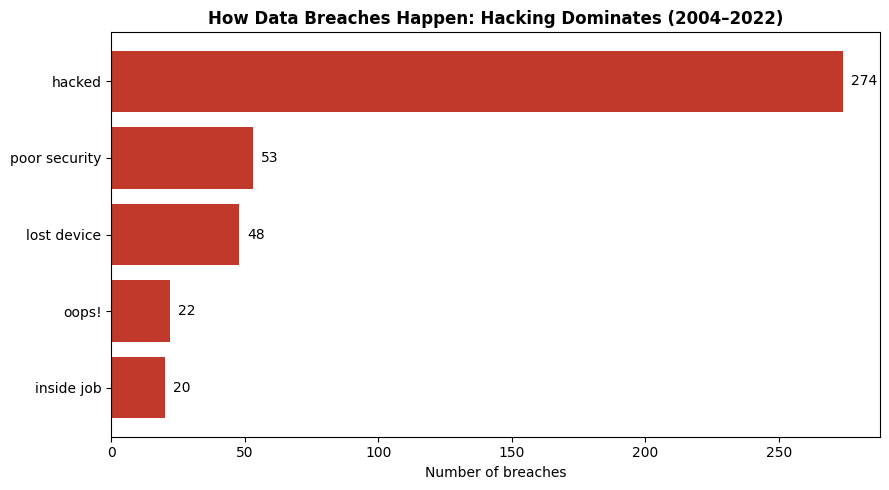

In [10]:
import matplotlib.pyplot as plt

# Chart 1: Breaches by method
method_counts = clean["method"].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.barh(method_counts.index, method_counts.values, color="#c0392b")
plt.xlabel("Number of breaches")
plt.title("How Data Breaches Happen: Hacking Dominates (2004–2022)", fontweight="bold")
plt.gca().invert_yaxis()  # biggest at top

# Add value labels on each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 3, bar.get_y() + bar.get_height()/2, int(width), va="center")

plt.tight_layout()
plt.savefig("chart1_methods.png", dpi=150, bbox_inches="tight")
plt.show()

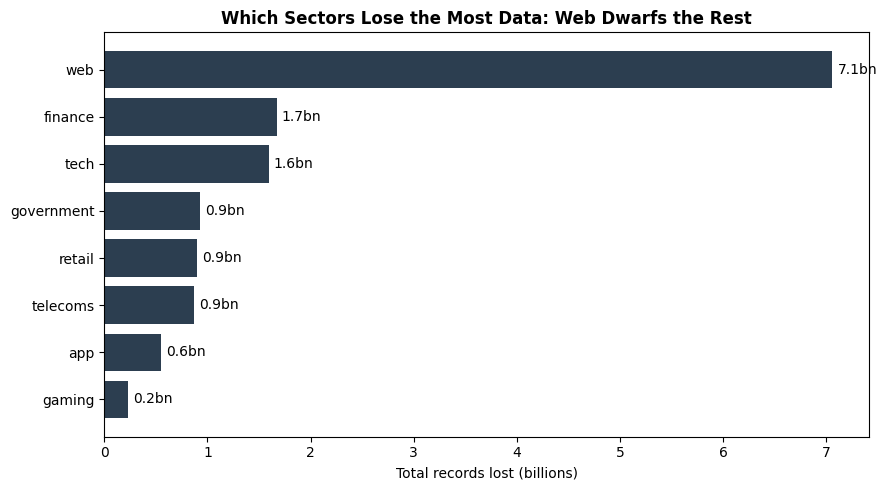

In [11]:
# Chart 2: Top 8 sectors by total records lost (in billions)
sector_top = sector_analysis.head(8).copy()
sector_billions = (sector_top["total_records_lost"] / 1_000_000_000)

plt.figure(figsize=(9, 5))
bars = plt.barh(sector_billions.index, sector_billions.values, color="#2c3e50")
plt.xlabel("Total records lost (billions)")
plt.title("Which Sectors Lose the Most Data: Web Dwarfs the Rest", fontweight="bold")
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, f"{width:.1f}bn", va="center")

plt.tight_layout()
plt.savefig("chart2_sectors_severity.png", dpi=150, bbox_inches="tight")
plt.show()

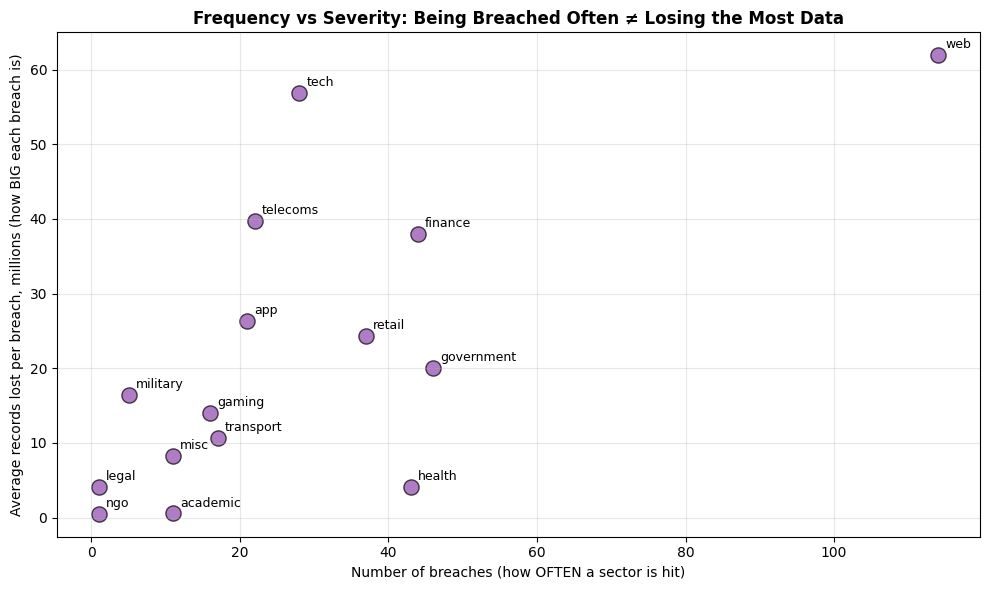

In [12]:
# Chart 3: Frequency vs Severity - do often-breached sectors lose the most per breach?
sector_scatter = sector_analysis.copy()
sector_scatter["avg_millions"] = sector_scatter["avg_records_per_breach"] / 1_000_000

plt.figure(figsize=(10, 6))
plt.scatter(sector_scatter["number_of_breaches"],
            sector_scatter["avg_millions"],
            s=120, color="#8e44ad", alpha=0.7, edgecolors="black")

# Label each point with its sector name
for sector, row in sector_scatter.iterrows():
    plt.annotate(sector,
                 (row["number_of_breaches"], row["avg_millions"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=9)

plt.xlabel("Number of breaches (how OFTEN a sector is hit)")
plt.ylabel("Average records lost per breach, millions (how BIG each breach is)")
plt.title("Frequency vs Severity: Being Breached Often \u2260 Losing the Most Data", fontweight="bold")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("chart3_frequency_vs_severity.png", dpi=150, bbox_inches="tight")
plt.show()

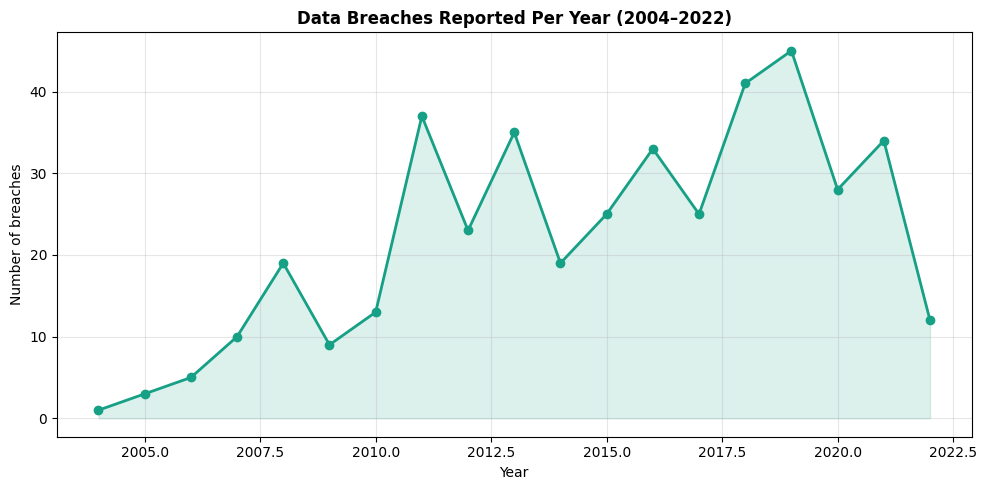

In [13]:
# Chart 4: Breaches over time by year
year_data = clean.groupby("year").size()

plt.figure(figsize=(10, 5))
plt.plot(year_data.index, year_data.values, marker="o", linewidth=2, color="#16a085")
plt.fill_between(year_data.index, year_data.values, alpha=0.15, color="#16a085")
plt.xlabel("Year")
plt.ylabel("Number of breaches")
plt.title("Data Breaches Reported Per Year (2004\u20132022)", fontweight="bold")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("chart4_breaches_over_time.png", dpi=150, bbox_inches="tight")
plt.show()